# FACE_MASK_DETECTION

#### Training_Model

In [6]:
pip uninstall tensorflow tensorflow-intel keras -y

Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0
Found existing installation: tensorflow-intel 2.15.0
Uninstalling tensorflow-intel-2.15.0:
  Successfully uninstalled tensorflow-intel-2.15.0
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip cache purge

Files removed: 1677 (3961.5 MB)
Directories removed: 950
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip show tensorflow

Name: tensorflow
Version: 2.15.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\vv\appdata\local\programs\python\python310\lib\site-packages
Requires: tensorflow-intel
Required-by: deepface, retina-face
Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import keras
from keras_preprocessing.image import ImageDataGenerator

from keras.callbacks import ModelCheckpoint

# for accuracy and Loss graph
import matplotlib.pyplot as plt

import tensorflow


In [3]:
train_data_path=r"C:\Users\vv\Downloads\New folder\MASK DETECTION\Face Mask Dataset\Train"
validation_data_path=r"C:\Users\vv\Downloads\New folder\MASK DETECTION\Face Mask Dataset\Validation"


In [4]:
# show augmented Images
def plotImages(images_arr):
    fig, axes=plt.subplots(1, 5, figsize=(20, 20))
    axes=axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)

    plt.tight_layout()
    plt.show()

# this is for augmentation configuration and we will use for traing
# It generates more images using below parameters

train_datagen = ImageDataGenerator(rescale=1./255, # to rescale the image in range of [0,1]
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2, # to randomly zoom the images
    shear_range=0.2, #to randomly shear the images
    horizontal_flip=True,
    fill_mode='nearest')

# this is a geenrator that will read found pictures
# at train_data_path and, indefinitely generate

training_data=train_datagen.flow_from_directory(train_data_path,target_size=(200,200),
                                               batch_size=128, class_mode='categorical')


    

Found 10000 images belonging to 2 classes.


In [5]:
training_data.class_indices

{'WithMask': 0, 'WithoutMask': 1}

In [6]:
# augmentation config for validation
# only rescaling

valid_datagen= ImageDataGenerator(rescale=1./255)


valid_data=valid_datagen.flow_from_directory(validation_data_path, target_size=(200,200), batch_size=128, class_mode='categorical')


Found 800 images belonging to 2 classes.


In [7]:
# print(type(training_data))
# print(len(training_data))

# print(type(training_data[0]))
# print(len(training_data[0]))

# print(type(training_data[0][0]))
# print(training_data[0][0].shape)

# print(type(training_data[0][1]))
# print(training_data[0][1])

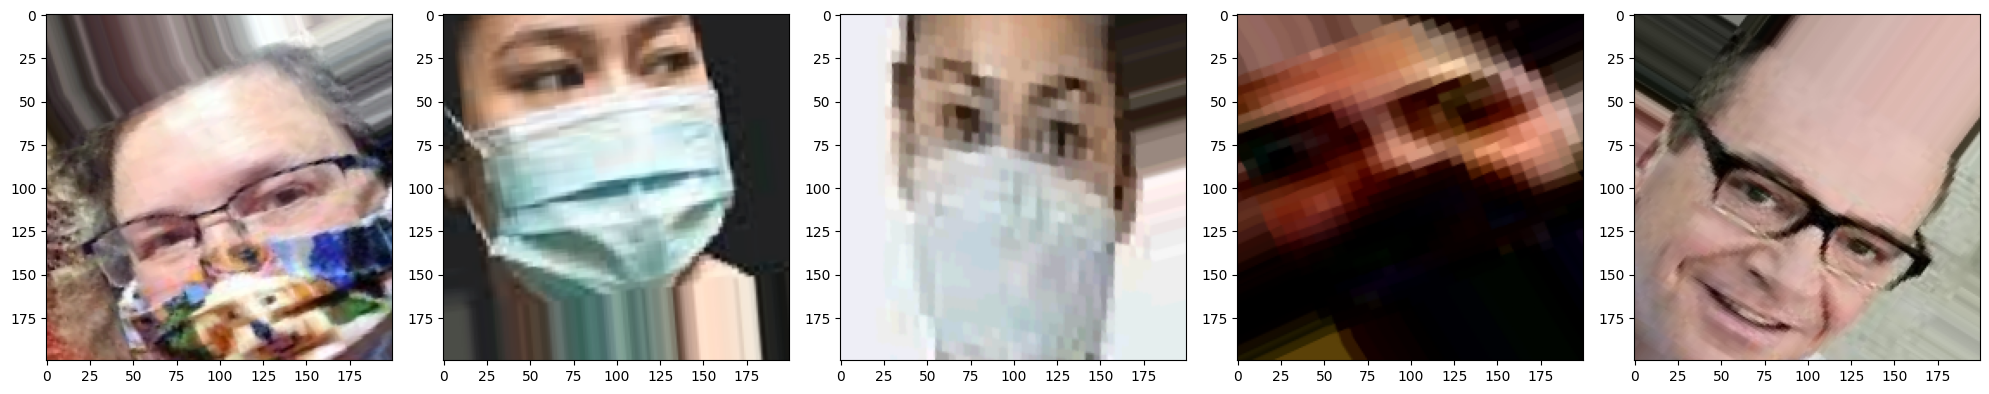

In [8]:
# showing augmented images
batch_images, batch_labels = training_data[0]

images = [batch_images[i] for i in range(5)]
plotImages(images)


# images=[training_data[0][0][0][0] for i in range(5)]
# plotImages(images)
# training_data[0]      # first batch
# [0]                   # images array
# [0]                   # first image
# [0]                   # first row of pixels

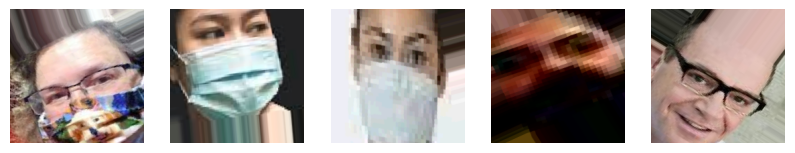

In [9]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(batch_images[i])
    plt.axis("off")

plt.show()

In [10]:
model_path='model/face_mask.h5'
checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list=[checkpoint]

In [11]:
from tensorflow import keras
from tensorflow.keras.optimizers import Adam

cnn_model = keras.models.Sequential([

    keras.layers.Conv2D(filters=32, kernel_size=5, activation='relu', input_shape=(200,200,3)),
    keras.layers.MaxPooling2D(pool_size=(4,4)),

    keras.layers.Conv2D(filters=64, kernel_size=4, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(3,3)),

    keras.layers.Conv2D(filters=128,kernel_size=3, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Conv2D(filters=256, kernel_size=2, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.25),
    
    keras.layers.Dense(units=2, activation='softmax')])


cnn_model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

# Batch Normalization is a technique that makes deep learning models train much faster and more reliably. 
# It acts like a stabilization layer that adjusts and standardizes the data flowing between the hidden layers of a neural network.

In [12]:
history=cnn_model.fit(training_data,epochs=2, verbose=1,  validation_data=valid_data, callbacks=callbacks_list)

Epoch 1/2


79/79 [==============================] - ETA: 0s - loss: 0.3788 - accuracy: 0.8305   
Epoch 1: val_accuracy improved from -inf to 0.94500, saving model to model\face_mask.h5
79/79 [==============================] - 256s 3s/step - loss: 0.3788 - accuracy: 0.8305 - val_loss: 0.1611 - val_accuracy: 0.9450
Epoch 2/2


C:\Users\vv\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


79/79 [==============================] - ETA: 0s - loss: 0.2389 - accuracy: 0.9112  
Epoch 2: val_accuracy improved from 0.94500 to 0.97500, saving model to model\face_mask.h5
79/79 [==============================] - 255s 3s/step - loss: 0.2389 - accuracy: 0.9112 - val_loss: 0.1044 - val_accuracy: 0.9750


In [13]:
cnn_model.save('model/face_mask.h5')
print("Model Saved")

Model Saved


In [18]:
pred_prob = cnn_model.predict(batch_images, verbose=0)

print("Raw Output:", pred_prob)

label_index = np.argmax(pred_prob)

print("Predicted Class:", label_index)

Raw Output: [[3.10682476e-01 6.89317524e-01]
 [9.91123557e-01 8.87648389e-03]
 [9.76225376e-01 2.37746723e-02]
 [8.84218574e-01 1.15781419e-01]
 [1.83557138e-01 8.16442907e-01]
 [7.27044716e-02 9.27295506e-01]
 [4.93392423e-02 9.50660765e-01]
 [9.99945641e-01 5.43525093e-05]
 [9.86977279e-01 1.30227450e-02]
 [4.88899387e-02 9.51110065e-01]
 [9.98172998e-01 1.82703405e-03]
 [5.33232130e-02 9.46676791e-01]
 [4.41348590e-02 9.55865085e-01]
 [9.96161222e-01 3.83871072e-03]
 [1.06981032e-01 8.93019021e-01]
 [9.76953030e-01 2.30470244e-02]
 [5.44097163e-02 9.45590258e-01]
 [9.94325221e-01 5.67472493e-03]
 [2.76918896e-02 9.72308159e-01]
 [1.50892800e-02 9.84910727e-01]
 [9.76832747e-01 2.31672712e-02]
 [9.89703119e-01 1.02968412e-02]
 [7.49216974e-02 9.25078273e-01]
 [3.24667059e-02 9.67533231e-01]
 [3.75260897e-02 9.62473929e-01]
 [2.38952413e-02 9.76104736e-01]
 [5.21205664e-01 4.78794396e-01]
 [8.54369462e-01 1.45630509e-01]
 [9.81242657e-01 1.87573265e-02]
 [9.25758779e-02 9.07424152e-01

In [20]:
# =========================
# Face Mask Detection 
# =========================

import cv2
import os
import numpy as np
from keras.models import load_model

# =========================
# LOAD MODEL
# =========================

model = load_model('model/face_mask.h5')

IMG_WIDTH = 200
IMG_HEIGHT = 200

# =========================
# FOLDERS SETUP
# =========================

base_path = r"C:\Users\vv\Downloads\New folder\MASK DETECTION\faces"

with_mask_path = os.path.join(base_path, "with_mask")
without_mask_path = os.path.join(base_path, "without_mask")

os.makedirs(with_mask_path, exist_ok=True)
os.makedirs(without_mask_path, exist_ok=True)

# =========================
# LOAD HAAR CASCADE
# =========================

face_cascade = cv2.CascadeClassifier(r"C:\Users\vv\OneDrive\Desktop\PYTHON\haarcascade_frontalface_default.xml")

if face_cascade.empty():
    print("ERROR: Haar Cascade not loaded")
    exit()

# =========================
# START CAMERA
# =========================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("ERROR: Webcam not opening")
    exit()

print("Press ESC to Exit")

# =========================
# VARIABLES
# =========================

img_count_full = 0

font = cv2.FONT_HERSHEY_SIMPLEX
fontScale = 1
thickness = 2

# =========================
# MAIN LOOP
# =========================

while True:

    img_count_full += 1

    ret, color_img = cap.read()

    if not ret:
        continue

    # Mirror view
    color_img = cv2.flip(color_img, 1)

    gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray_img,scaleFactor=1.1,minNeighbors=6,minSize=(80, 80))

    img_count = 0

    for (x, y, w, h) in faces:

        img_count += 1

        org = (x - 10, y - 10)

        face_crop = color_img[y:y+h, x:x+w]

        try:

            # =========================
            # DIRECT PREDICTION (NO DISK IO)
            # =========================

            img = cv2.resize(face_crop, (IMG_WIDTH, IMG_HEIGHT))
            img = img.astype("float32") / 255.0
            img = np.expand_dims(img, axis=0)

            pred_prob = model.predict(img, verbose=0)[0]

            pred = np.argmax(pred_prob)
            confidence = float(np.max(pred_prob))

            # =========================
            # FIXED LABEL MAPPING
            # =========================
            # 0 -> Without Mask
            # 1 -> With Mask

            if pred == 1:

                class_label = "User with Mask"
                color = (0, 255, 0)

                print("User with mask - confidence =", confidence)

                if img_count_full % 10 == 0:
                    cv2.imwrite(os.path.join(with_mask_path,f"{img_count_full}_{img_count}_face.jpg"),face_crop)

            else:

                class_label = "User without Mask"
                color = (0, 0, 255)

                print("User without mask - confidence =", confidence)

                if img_count_full % 10 == 0:
                    cv2.imwrite(os.path.join(without_mask_path,f"{img_count_full}_{img_count}_face.jpg"),face_crop)

            # =========================
            # DRAW BOX
            # =========================

            cv2.rectangle(color_img,(x, y),(x + w, y + h),color,3)

            # =========================
            # DRAW TEXT
            # =========================

            cv2.putText(color_img,f"{class_label} {confidence * 100:.1f}%",org,font,fontScale,color,thickness,cv2.LINE_AA)

        except Exception as e:
            print("Prediction Error:", e)

    # =========================
    # SHOW OUTPUT
    # =========================

    cv2.imshow("LIVE Face Mask Detection", color_img)

    if cv2.waitKey(1) & 0xFF == 27:
        break

# =========================
# CLEANUP
# =========================

cap.release()
cv2.destroyAllWindows()

Press ESC to Exit
User without mask - confidence = 0.8975620865821838
User without mask - confidence = 0.9013744592666626
User without mask - confidence = 0.9132997393608093
User without mask - confidence = 0.904330849647522
User without mask - confidence = 0.8974335789680481
User without mask - confidence = 0.9083490371704102
User without mask - confidence = 0.9092732667922974
User without mask - confidence = 0.9144257307052612
User without mask - confidence = 0.915482759475708
User without mask - confidence = 0.9143394231796265


In [ ]:
# # own CNN Architecture- Mask-Detection CNN.ipynb

# # import packages
# import cv2
# import os
# from keras.models import load_model
# from keras.preprocessing.image import load_img,  img_to_array
# import numpy as np

# model=load_model('model/face_mask.h5')

# img_width, img_height=200, 200

# # Load the Cascade face Classifier

# face_cascade = cv2.CascadeClassifier(r"C:\Users\vv\OneDrive\Desktop\PYTHON\haarcascade_frontalface_default.xml")

# #start webcam

# cap=cv2.VideoCapture(0)

# img_count_full=0
# #parameters for text
# # font
# font=cv2.FONT_HERSHEY_SIMPLEX
# #ORG
# org=(1,1)
# class_label=" "
# #font_scale
# fontscale=1
# # blue colour in BGR
# color=(255,0,0)
# #LINE thickness
# thickness=2

# # start reading images and prediction
# while True:
#     img_count_full += 1
#     # load image from webcam
#     response, color_img= cap.read()


#     if response==False:
#         break

#     # Convert to gray_scale

#     gray_img=cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

#     # Detect the faces
#     faces=face_cascade.detectMultiScale(gray_img, 1.1, 6)  # 1.1, 3 for mp4

#     # take face then predict class mask or without mask then draw rectangle and then text then display image

#     img_count=0
#     for (x, y, w, h) in faces:
#         org== (x-10, y-10)
#         img_count +=1
#         color_face=color_img[y:y+h, x:x+w] # color_face
#         cv2.imwrite(r"C:\Users\vv\Downloads\New folder\MASK DETECTION\faces\%d%dface.jpg"%(img_count_full, img_count), color_face)
#         img=load_img(r"C:\Users\vv\Downloads\New folder\MASK DETECTION\faces\%d%dface.jpg"%(img_count_full, img_count), target_size=(img_width, img_height))

#         img=img_to_array(img)/255
#         img = np.expand_dims(img, axis=0)
#         pred_prob=model.predict(img)
#         pred=np.argmax(pred_prob)

#         if pred==0:
#             print(" User with mask - predict = ", pred_prob[0][0])
#             class_label="Mask"
#             color=(255,0,0)
#             cv2.imwrite(r"C:\Users\vv\Downloads\New folder\MASK DETECTION\faces\with_mask\%d%dface.jpg"%(img_count_full, img_count), color_face)

#         else:
#             print("User not Wearing Mask - prob =", pred_prob[0][1])
#             class_label= " No Mask "
#             color=(0,255,0)
#             cv2.imwrite(r"C:\Users\vv\Downloads\New folder\MASK DETECTION\faces\without_mask\%d%dface.jpg"%(img_count_full, img_count), color_face)

#         cv2.rectangle(color_img, (x,y), (x+w, y+h), (0,0,255), 3)

#         fontScale = 1
#         cv2.putText(color_img, class_label, org, font, fontScale, color, thickness, cv2.LINE_AA)
#             # cv2.LINE_AA stands for Anti-Aliased Line. 
#             # It is a setting in OpenCV used to draw smooth, high-quality graphics rather than a specific deep learning algorithm.
#             # Smooths edges: Normal digital lines look like jagged stairs when zoomed in.
#             # Blends pixels: It uses a mathematical trick (anti-aliasing) to fade the edges of a line into the background.
#             # Look professional: It makes lines, text, and shapes look crisp and clean.
#             # Object Detection: When a model finds an object (like a car or a face), it draws a box around it. 
#             # cv2.LINE_AA makes those bounding boxes clean and easy for humans to read.

#         # display image
#         cv2.imshow("LIVE face  Mask Detection", color_img)

#         if cv2.waitKey(1) & 0xFF == 27:
#             break
        

# # Release the video Capture
# cap.release()
# cv2.destroyAllWindows()

